# Battery SOC and EMS scaling

Goal: use the measured battery discharge data to make a simple SOC curve, then scale the
battery energy to the EMS demonstration scale.

The measured battery is larger than the EMS demo. Therefore:

measured_capacity_Wh = integral(V * I * dt)

EMS_capacity_Wh = 100 mWh / 1000 = 0.100 Wh

scaling_factor = EMS_capacity_Wh / measured_capacity_Wh

The voltage-SOC curve is still useful because it gives a practical relation between measured
voltage and battery state.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes the notebook work both from the repo root and from its own folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load and inspect the raw charge and discharge data


In [2]:
charge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv"
discharge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_DISCHARGE_ina226_soc_log_20260421_095715.csv"

charge_raw = pd.read_csv(charge_file)
discharge_raw = pd.read_csv(discharge_file)

print("Charge file rows:", len(charge_raw))
print("Discharge file rows:", len(discharge_raw))
display(charge_raw.head())
display(discharge_raw.head())


Charge file rows: 56108
Discharge file rows: 78477


,pc_time,elapsed_s,bus_V,current_mA,power_mW,shunt_mV,voltage_corrected_V,soc_voltage_percent,soc_percent,mode
0,2026-04-20 18:09:02.387,0.001,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST
1,2026-04-20 18:09:02.388,0.002,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST
2,2026-04-20 18:09:02.972,0.587,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST
3,2026-04-20 18:09:03.974,1.589,0.0000,-0.025,0.0,-0.0025,0.0000,0.0,0.0,REST
4,2026-04-20 18:09:04.976,2.590,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST


,pc_time,elapsed_s,bus_V,current_mA,power_mW,shunt_mV,voltage_corrected_V,soc_voltage_percent,soc_percent,mode
0,2026-04-21 09:57:17.740,0.001,4.3325,0.000,0.0,0.0000,4.3325,82.31,82.31,REST
1,2026-04-21 09:57:17.741,0.002,4.3337,-0.025,0.0,-0.0025,4.3338,82.31,82.31,REST
2,2026-04-21 09:57:18.039,0.300,4.3337,-0.025,0.0,-0.0025,4.3338,82.31,82.31,REST
3,2026-04-21 09:57:19.042,1.303,4.3337,-0.025,0.0,-0.0025,4.3338,82.31,82.31,REST
4,2026-04-21 09:57:20.046,2.307,4.3325,-0.025,0.0,-0.0025,4.3325,82.31,82.31,REST


## 2. Plot the raw current and voltage data


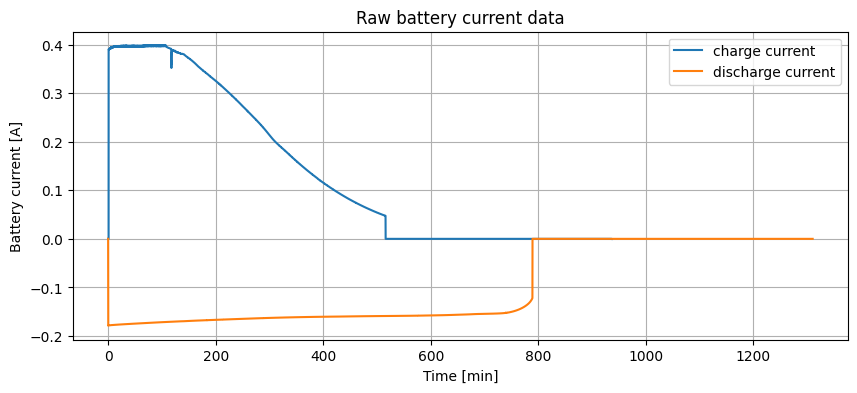

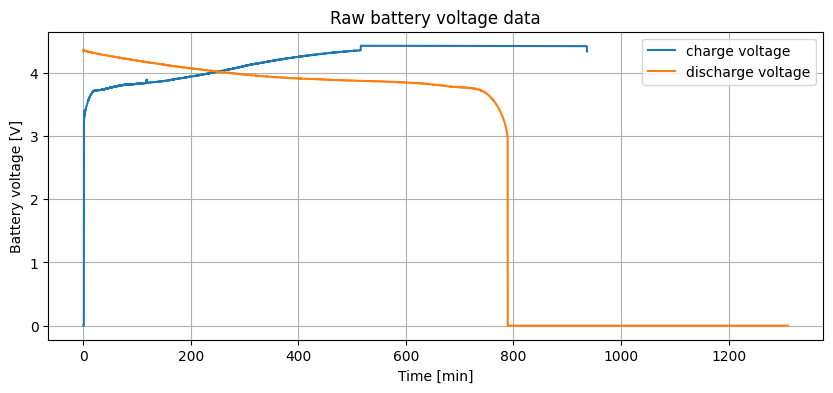

In [3]:
charge_time_min = charge_raw["elapsed_s"] / 60
discharge_time_min = discharge_raw["elapsed_s"] / 60

plt.figure(figsize=(10, 4))
plt.plot(charge_time_min, charge_raw["current_mA"] / 1000, label="charge current")
plt.plot(discharge_time_min, discharge_raw["current_mA"] / 1000, label="discharge current")
plt.title("Raw battery current data")
plt.xlabel("Time [min]")
plt.ylabel("Battery current [A]")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(charge_time_min, charge_raw["voltage_corrected_V"], label="charge voltage")
plt.plot(discharge_time_min, discharge_raw["voltage_corrected_V"], label="discharge voltage")
plt.title("Raw battery voltage data")
plt.xlabel("Time [min]")
plt.ylabel("Battery voltage [V]")
plt.legend()
plt.grid(True)
plt.show()


## 3. Select only the active charge and discharge regions

I remove rest periods by requiring a clear current:

- charge is active when current > 0.05 A
- discharge is active when current < -0.05 A

This avoids integrating long zero-current tails.


In [4]:
charge = charge_raw[charge_raw["current_mA"] > 50].copy()
discharge = discharge_raw[discharge_raw["current_mA"] < -50].copy()

charge["time_min"] = (charge["elapsed_s"] - charge["elapsed_s"].iloc[0]) / 60
discharge["time_min"] = (discharge["elapsed_s"] - discharge["elapsed_s"].iloc[0]) / 60

print("Active charge rows:", len(charge))
print("Active discharge rows:", len(discharge))
display(charge[["time_min", "voltage_corrected_V", "current_mA", "power_mW"]].head())
display(discharge[["time_min", "voltage_corrected_V", "current_mA", "power_mW"]].head())


Active charge rows: 30459
Active discharge rows: 47246


,time_min,voltage_corrected_V,current_mA,power_mW
54,0.000000,3.1414,389.725,1385.000
55,0.016700,3.1596,390.250,1394.375
56,0.033400,3.1660,390.150,1396.250
57,0.050100,3.1713,389.800,1396.875
58,0.066783,3.1759,390.200,1400.625


,time_min,voltage_corrected_V,current_mA,power_mW
15,0.000000,4.3666,-178.750,746.250
16,0.016683,4.3655,-178.850,746.875
17,0.033350,4.3655,-178.875,746.875
18,0.050133,4.3654,-178.750,746.250
19,0.066800,4.3641,-178.700,746.250


## 4. Check the selected active regions


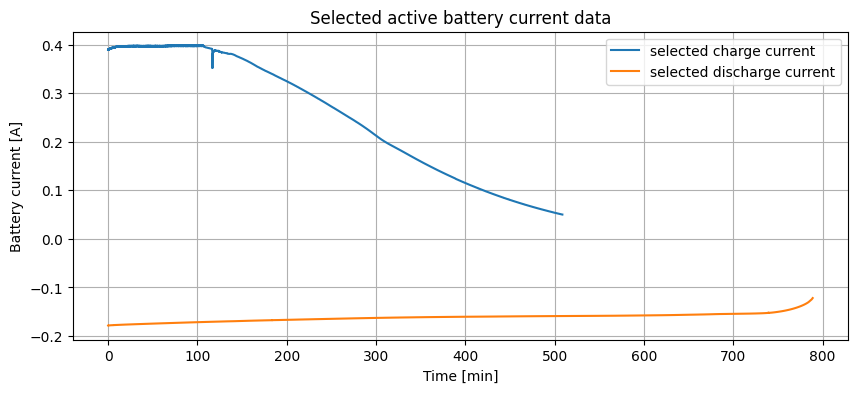

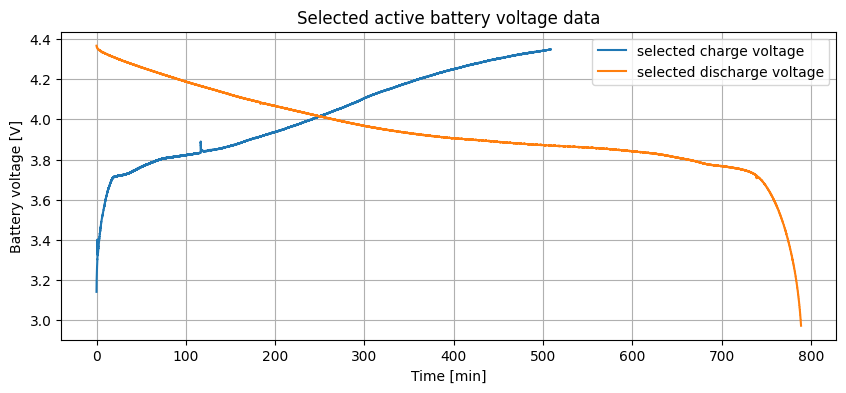

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(charge["time_min"], charge["current_mA"] / 1000, label="selected charge current")
plt.plot(discharge["time_min"], discharge["current_mA"] / 1000, label="selected discharge current")
plt.title("Selected active battery current data")
plt.xlabel("Time [min]")
plt.ylabel("Battery current [A]")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(charge["time_min"], charge["voltage_corrected_V"], label="selected charge voltage")
plt.plot(discharge["time_min"], discharge["voltage_corrected_V"], label="selected discharge voltage")
plt.title("Selected active battery voltage data")
plt.xlabel("Time [min]")
plt.ylabel("Battery voltage [V]")
plt.legend()
plt.grid(True)
plt.show()


## 5. Calculate SOC from coulomb counting

For discharge we use positive current by changing the sign:

discharge_current_A = - current_A

capacity_removed_Ah = sum(discharge_current_A * dt_h)

SOC starts at 100 percent and ends at 0 percent:

SOC_percent = 100 * (1 - capacity_removed_Ah / total_capacity_Ah)


In [6]:
discharge["time_h"] = discharge["time_min"] / 60
discharge["dt_h"] = discharge["time_h"].diff().fillna(0)
discharge["discharge_current_A"] = -discharge["current_mA"] / 1000
discharge["discharge_power_W"] = discharge["discharge_current_A"] * discharge["voltage_corrected_V"]

discharge["capacity_removed_Ah"] = (discharge["discharge_current_A"] * discharge["dt_h"]).cumsum()
discharge["energy_removed_Wh"] = (discharge["discharge_power_W"] * discharge["dt_h"]).cumsum()

MEASURED_BATTERY_CAPACITY_AH = discharge["capacity_removed_Ah"].iloc[-1]
MEASURED_BATTERY_ENERGY_WH = discharge["energy_removed_Wh"].iloc[-1]

discharge["SOC_percent"] = 100 * (1 - discharge["capacity_removed_Ah"] / MEASURED_BATTERY_CAPACITY_AH)
discharge["SOC_percent"] = discharge["SOC_percent"].clip(0, 100)

print(f"Measured discharge capacity: {MEASURED_BATTERY_CAPACITY_AH:.3f} Ah")
print(f"Measured discharge energy:   {MEASURED_BATTERY_ENERGY_WH:.3f} Wh")


Measured discharge capacity: 2.126 Ah
Measured discharge energy:   8.401 Wh


## 6. Plot the calculated SOC curve


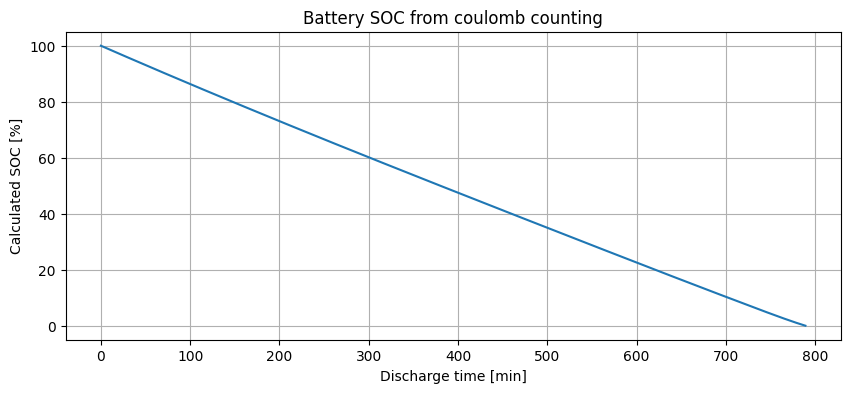

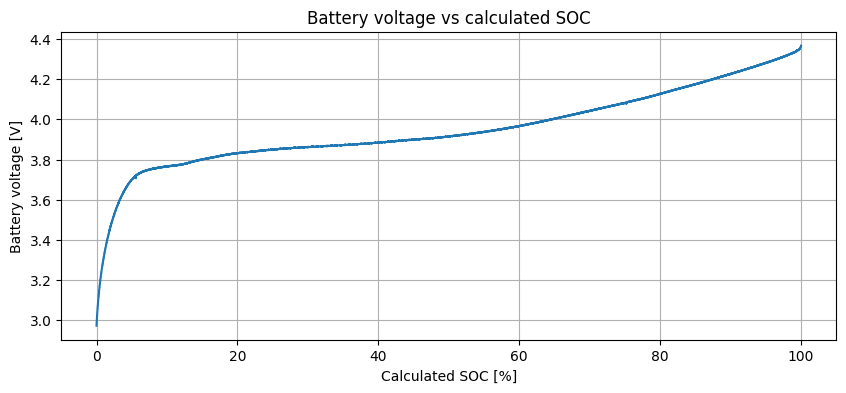

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(discharge["time_min"], discharge["SOC_percent"])
plt.title("Battery SOC from coulomb counting")
plt.xlabel("Discharge time [min]")
plt.ylabel("Calculated SOC [%]")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(discharge["SOC_percent"], discharge["voltage_corrected_V"])
plt.title("Battery voltage vs calculated SOC")
plt.xlabel("Calculated SOC [%]")
plt.ylabel("Battery voltage [V]")
plt.grid(True)
plt.show()


## 7. Scale the battery to the EMS demonstration size

The measured battery energy is not the energy used directly in the EMS demo. Wescale it to:

EMS battery capacity = 100 mWh = 0.100 Wh

This means the SOC curve shape stays the same, but the energy axis is compressed to the demo scale.


In [8]:
EMS_BATTERY_CAPACITY_MILLIWATT_HOUR = 100.0
EMS_BATTERY_CAPACITY_WH = EMS_BATTERY_CAPACITY_MILLIWATT_HOUR / 1000

BATTERY_ENERGY_SCALE_FACTOR = EMS_BATTERY_CAPACITY_WH / MEASURED_BATTERY_ENERGY_WH

discharge["ems_energy_removed_mWh"] = discharge["energy_removed_Wh"] * BATTERY_ENERGY_SCALE_FACTOR * 1000
discharge["ems_energy_remaining_mWh"] = EMS_BATTERY_CAPACITY_MILLIWATT_HOUR - discharge["ems_energy_removed_mWh"]
discharge["ems_energy_remaining_mWh"] = discharge["ems_energy_remaining_mWh"].clip(0, EMS_BATTERY_CAPACITY_MILLIWATT_HOUR)

print(f"EMS battery capacity: {EMS_BATTERY_CAPACITY_MILLIWATT_HOUR:.1f} mWh")
print(f"Energy scale factor:  {BATTERY_ENERGY_SCALE_FACTOR:.5f}")


EMS battery capacity: 100.0 mWh
Energy scale factor:  0.01190


## 8. Plot the scaled battery energy


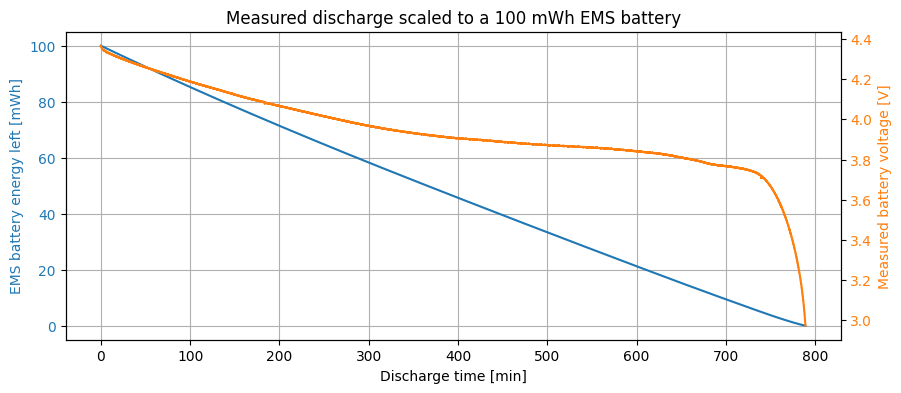

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(discharge["time_min"], discharge["ems_energy_remaining_mWh"], color="tab:blue", label="EMS energy left")
ax1.set_xlabel("Discharge time [min]")
ax1.set_ylabel("EMS battery energy left [mWh]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(discharge["time_min"], discharge["voltage_corrected_V"], color="tab:orange", label="battery voltage")
ax2.set_ylabel("Measured battery voltage [V]", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Measured discharge scaled to a 100 mWh EMS battery")
plt.show()


## 9. Critical checks and app values

The measured physical battery could deliver more than 100 mW. For the EMS demo, the useful
battery output power is set  to the maximum scaled demand, which is 100 mW = 0.100 W.


In [10]:
demand_file = PROJECT_ROOT / "app/python/data/variable_load_signal/scaled_may_power_profile_15min.csv"
demand_profile = pd.read_csv(demand_file)

BATTERY_FULL_VOLTAGE = discharge["voltage_corrected_V"].iloc[0]
BATTERY_EMPTY_VOLTAGE = discharge["voltage_corrected_V"].iloc[-1]
MEASURED_BATTERY_MAX_DISCHARGE_POWER_W = discharge["discharge_power_W"].max()
BATTERY_MAX_DISCHARGE_POWER_W = demand_profile["power_mW"].max() / 1000

battery_parameters = pd.DataFrame(
    {
        "parameter": [
            "EMS_BATTERY_CAPACITY_MILLIWATT_HOUR",
            "BATTERY_FULL_VOLTAGE",
            "BATTERY_EMPTY_VOLTAGE",
            "MEASURED_BATTERY_ENERGY_WH",
            "MEASURED_BATTERY_MAX_DISCHARGE_POWER_W",
            "BATTERY_MAX_DISCHARGE_POWER_W",
        ],
        "value": [
            EMS_BATTERY_CAPACITY_MILLIWATT_HOUR,
            BATTERY_FULL_VOLTAGE,
            BATTERY_EMPTY_VOLTAGE,
            MEASURED_BATTERY_ENERGY_WH,
            MEASURED_BATTERY_MAX_DISCHARGE_POWER_W,
            BATTERY_MAX_DISCHARGE_POWER_W,
        ],
        "unit": ["mWh", "V", "V", "Wh", "W", "W"],
        "meaning": [
            "Chosen EMS demo battery energy",
            "Measured voltage at start of discharge",
            "Measured voltage at end of discharge",
            "Energy measured in the real battery test",
            "Physical measured max discharge power",
            "EMS design output limit based on 100 mW max demand",
        ],
    }
)

display(battery_parameters)


,parameter,value,unit,meaning
0,EMS_BATTERY_CAPACITY_MILLIWATT_HOUR,100.000000,mWh,Chosen EMS demo battery energy
1,BATTERY_FULL_VOLTAGE,4.366600,V,Measured voltage at start of discharge
2,BATTERY_EMPTY_VOLTAGE,2.972800,V,Measured voltage at end of discharge
3,MEASURED_BATTERY_ENERGY_WH,8.401420,Wh,Energy measured in the real battery test
4,MEASURED_BATTERY_MAX_DISCHARGE_POWER_W,0.780879,W,Physical measured max discharge power
5,BATTERY_MAX_DISCHARGE_POWER_W,0.100000,W,EMS design output limit based on 100 mW max de...
